<div style="background:linear-gradient(135deg,#431407 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ffedd5;font-weight:700;text-transform:uppercase">Chapter 99 · Econometrics & Panel Data</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Econometrics &amp; Panel Data</div>
  <div style="font-size:15px;color:#fff7ed;max-width:740px;line-height:1.6">Watch omitted-variable bias inflate a pooled estimate, remove it with fixed effects, prove the fix against the hidden confounder, and recover a causal slope with two-stage least squares, library-first with statsmodels.</div>
  <div style="margin-top:16px;font-size:13px;color:#ffedd5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## Econometrics: pulling cause out of observational data
Library-first with `statsmodels`. We watch omitted-variable bias inflate a pooled estimate, remove it with fixed effects, prove the fix by revealing the hidden confounder, and run a two-stage least squares instrumental-variable demo.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#ea580c"; DEEP="#c2410c"; LIGHT="#fdba74"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">DEMO 1 &#183; THE BIASED ESTIMATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Pooled OLS overstates the union premium</div>
<div style="color:#4a5578;margin-top:6px">A plain regression ignores who unionizes, and unionizers differ in unmeasured ability.</div>
</div>

In [2]:
try:
    panel = pd.read_excel('../../data/ch99_panel.xlsx', sheet_name='Panel')
except FileNotFoundError:
    panel = pd.read_excel(BASE + 'ch99_panel.xlsx', sheet_name='Panel')
print(f'{panel.worker_id.nunique()} workers x {panel.year.nunique()} years = {len(panel)} rows')
print(f'corr(union, ability) = {panel[["union","ability_index"]].corr().iloc[0,1]:.2f}   (the endogeneity)')
panel.head(3)

160 workers x 4 years = 640 rows
corr(union, ability) = 0.37   (the endogeneity)


,worker_id,year,tenure,union,ability_index,log_wage,wage
0,W000,2021,8,1,0.082,3.210,24.78
1,W000,2022,9,0,0.082,3.039,20.89
2,W000,2023,10,0,0.082,3.263,26.12


In [3]:
pooled = ols('log_wage ~ union + tenure', panel).fit()
b, (lo, hi) = pooled.params['union'], pooled.conf_int().loc['union']
print(f'Pooled OLS union coefficient = {b:.3f}  (95% CI {lo:.3f} to {hi:.3f})')
print('True premium built into the data = 0.15  ->  pooled OLS is biased UP.')

Pooled OLS union coefficient = 0.544  (95% CI 0.462 to 0.626)
True premium built into the data = 0.15  ->  pooled OLS is biased UP.


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 2 &#183; THE FIX</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fixed effects recover the truth</div>
<div style="color:#4a5578;margin-top:6px">Add a per-worker intercept so only within-worker variation is used; time-invariant ability is differenced out.</div>
</div>

In [4]:
fe = ols('log_wage ~ union + tenure + C(worker_id)', panel).fit()
b, (lo, hi) = fe.params['union'], fe.conf_int().loc['union']
print(f'Fixed-effects union coefficient = {b:.3f}  (95% CI {lo:.3f} to {hi:.3f})')
print('Recovered the true ~0.15 premium, without ever measuring ability.')

Fixed-effects union coefficient = 0.152  (95% CI 0.123 to 0.181)
Recovered the true ~0.15 premium, without ever measuring ability.


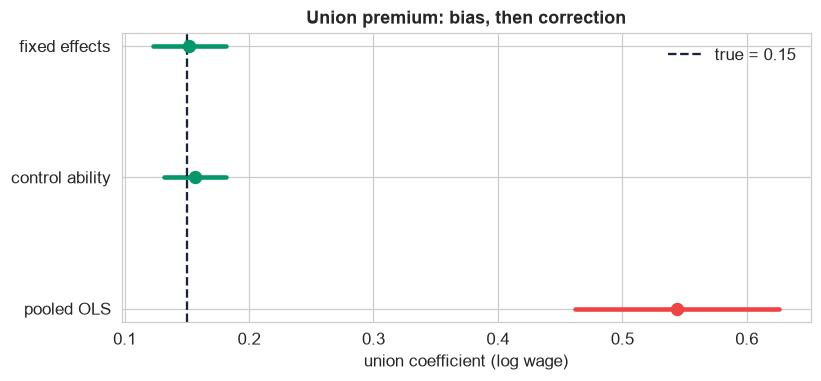

In [5]:
# Show the correction visually: pooled vs FE vs truth
ctrl = ols('log_wage ~ union + tenure + ability_index', panel).fit()
ests = {'pooled OLS': pooled, 'control ability': ctrl, 'fixed effects': fe}
fig, ax = plt.subplots(figsize=(7.6,3.6))
for i,(name,m) in enumerate(ests.items()):
    lo,hi = m.conf_int().loc['union']; c = m.params['union']
    col = RED if name=='pooled OLS' else GREEN
    ax.plot([lo,hi],[i,i], color=col, lw=3); ax.scatter(c,i,color=col,s=60,zorder=3)
ax.axvline(0.15, color=INK, ls='--', label='true = 0.15')
ax.set_yticks(range(len(ests))); ax.set_yticklabels(list(ests.keys()))
ax.set(title='Union premium: bias, then correction', xlabel='union coefficient (log wage)'); ax.legend()
plt.tight_layout(); plt.show()

<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 3 &#183; WHY IT WORKS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fixed effects = controlling for the confounder you cannot see</div>
<div style="color:#4a5578;margin-top:6px">Directly controlling for the hidden ability gives the same answer as fixed effects.</div>
</div>

In [6]:
print(f"control for ability : union = {ctrl.params['union']:.3f}")
print(f"fixed effects       : union = {fe.params['union']:.3f}")
print('Nearly identical: FE absorbs exactly the ability confounder, without needing to observe it.')
# Direction of omitted-variable bias = sign(corr(union,ability)) * sign(effect of ability)
print('\nOVB direction: union-ability corr > 0 and ability raises wage > 0  ->  upward bias, as seen.')

control for ability : union = 0.157
fixed effects       : union = 0.152
Nearly identical: FE absorbs exactly the ability confounder, without needing to observe it.

OVB direction: union-ability corr > 0 and ability raises wage > 0  ->  upward bias, as seen.


<div style="background:#fff7ed;border-left:5px solid #ea580c;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#c2410c;letter-spacing:1px">DEMO 4 &#183; INSTRUMENTAL VARIABLES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two-stage least squares on a simulated endogenous X</div>
<div style="color:#4a5578;margin-top:6px">When a confounder is time-varying, fixed effects will not help. A valid instrument and 2SLS can.</div>
</div>

In [7]:
rng = np.random.default_rng(7); n = 2000
u = rng.normal(0, 1, n)                 # unobserved confounder
z = rng.normal(0, 1, n)                 # instrument (independent of u)
x = 0.8*z + 0.9*u + rng.normal(0,0.5,n) # endogenous: depends on z AND u
y = 2.0*x + 1.5*u + rng.normal(0,0.5,n) # true causal effect of x on y is 2.0
d = pd.DataFrame({'y':y,'x':x,'z':z})
ols_biased = ols('y ~ x', d).fit().params['x']
stage1 = ols('x ~ z', d).fit(); d['x_hat'] = stage1.fittedvalues
iv_2sls = ols('y ~ x_hat', d).fit().params['x_hat']
print(f'true causal effect       = 2.00')
print(f'naive OLS (biased by u)  = {ols_biased:.2f}')
print(f'2SLS with instrument z   = {iv_2sls:.2f}  (recovers the truth)')

true causal effect       = 2.00
naive OLS (biased by u)  = 2.77
2SLS with instrument z   = 2.00  (recovers the truth)


**The Part in one idea:** clean residuals are necessary but not sufficient, the deepest question is whether the *design* identifies a causal effect. Fixed effects, instruments, and difference-in-differences are how econometrics answers it, closing the loop opened back in Chapter 91.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>